# CausalML API: Quick Start

This notebook provides a runnable walkthrough of the `CausalNavigator` API.
Each section pairs the API documentation with a live code cell so you can
test every method end-to-end.

The `CausalML` module is a high-level wrapper around the `causalml` library
designed to simplify causal inference workflows for observational studies. It
includes the `CausalNavigator` class for heterogeneous treatment effect
estimation, diagnostic methods for assumption validation, and helper
functions for data preprocessing and visualisation.

> Coming from the blog? Run cells top-to-bottom, no other setup needed (see
> Docker instructions below).

## Installation and Docker Setup

To ensure reproducibility, this project is containerised. Follow these steps
to build and run the analysis.

### 1. Build the Image

Run this command in the project root (where the `Dockerfile` is located):

```bash
./docker_build.sh
```

### 2. Run the Container

Start the Jupyter environment with volume mounting (to save your notebook
changes):

```bash
# Mac/Linux/WSL
./docker_jupyter.sh
```

### 3. Access the Project

- Click the `http://127.0.0.1:8888...` link in your terminal to open
  JupyterLab
- Open `CausalML.API.ipynb` to test the API (this file)
- Open `CausalML.example.ipynb` to see the full diabetes analysis

## Architecture

While `causalml` provides powerful meta-learners (S/T/X-Learners), the
native API requires significant boilerplate for data preprocessing,
assumption checking, and visualisation. `CausalNavigator` standardises that
workflow into a single class.

The core pipeline has three layers:

1. **Diagnostic Layer** - Verifies causal assumptions (specifically Common
   Support) before estimation
2. **Estimation Layer** - Wraps `causalml.inference.meta` classes
   (`BaseXRegressor`, etc.) and injects XGBoost as the standard base learner
3. **Interpretation Layer** - Provides built-in methods to visualise
   heterogeneity, abstracting away `matplotlib` complexity

## Setup

Import dependencies and the `CausalNavigator` class from `utils.py`.

In [3]:
# Enable auto-reloading so edits in utils.py update immediately.
%load_ext autoreload
%autoreload 2

import os
import warnings

import numpy as np

from utils import CausalNavigator, load_cdc_data, preprocess_for_causal

warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

### `load_cdc_data(filepath)`

**Purpose**: Robustly loads the CDC dataset from a local directory.

- **Inputs**: `filepath` (str) - relative path to the `.csv` file (e.g.,
  `data/unprocessed/file.csv`)
- **Behaviour**: Checks for file existence, removes duplicates, and casts all
  columns to `float` to ensure compatibility with XGBoost
- **Output**: A cleaned `pandas.DataFrame`

### `preprocess_for_causal(df, ...)`

**Purpose**: Splits the dataframe into the three required components for
`CausalML`:

1. **X (Covariates)** - features used to control for confounding
2. **T (Treatment)** - the binary intervention vector
3. **Y (Outcome)** - the target variable

> **Download the data first:**
> https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators
> Place the CSV in `data/unprocessed/` before running the next cell.

In [4]:
# Download the dataset and place it in data/unprocessed/ before running.
# Download link: https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators
filename = "diabetes_binary_health_indicators_BRFSS2015.csv"
DATA_PATH = os.path.join("data", "unprocessed", filename)
try:
    df_raw = load_cdc_data(DATA_PATH)
    # Use a subset of columns for the API demo.
    df_clean, X, T, Y = preprocess_for_causal(
        df_raw,
        treatment_col="PhysActivity",
        outcome_col="Diabetes_binary",
        covariate_cols=[
            "HighBP",
            "HighChol",
            "Age",
            "Income",
            "Sex",
            "GenHlth",
            "BMI",
        ],
    )
    # Subsample 10k rows for speed.
    sample_indices = np.random.choice(X.index, size=10000, replace=False)
    X_demo, T_demo, Y_demo = (
        X.loc[sample_indices],
        T.loc[sample_indices],
        Y.loc[sample_indices],
    )
    print(f"API Demo Data Loaded. Shape: {X_demo.shape}")
    display(X_demo.head())
except Exception as e:
    print(f"Error: {e}")

API Demo Data Loaded. Shape: (10000, 7)


,HighBP,HighChol,Age,Income,Sex,GenHlth,BMI
46287,1.0,1.0,13.0,7.0,0.0,4.0,19.0
28658,1.0,1.0,9.0,6.0,0.0,3.0,34.0
82683,0.0,0.0,8.0,1.0,0.0,5.0,27.0
103612,1.0,1.0,13.0,2.0,1.0,4.0,23.0
190214,1.0,1.0,11.0,8.0,1.0,2.0,35.0


## Class Reference: `CausalNavigator`

### Initialization

```python
navigator = CausalNavigator(
    learner_type='X',       # Options: 'S', 'T', 'X'
    control_name='Control',
    treatment_name='Treatment'
)
```

| Parameter | Description |
|-----------|-------------|
| `learner_type` | Meta-learner to use: `'S'`, `'T'`, or `'X'` |
| `control_name` | Label for the untreated group (used in plots) |
| `treatment_name` | Label for the treated group (used in plots) |

In [5]:
# Initialize the CausalNavigator.
navigator = CausalNavigator(
    learner_type="X", control_name="Sedentary", treatment_name="Active"
)

### `check_overlap(X, T)`

**Purpose**: Validates the Positivity/Overlap assumption.

- **Inputs**: Covariate matrix `X`, Treatment vector `T`
- **Output**: A density plot of Propensity Scores
- **Why use this**: If the distributions do not overlap, causal estimation is
  invalid. This method enforces safety before modelling - the treated and
  control groups must share common support across the feature space.

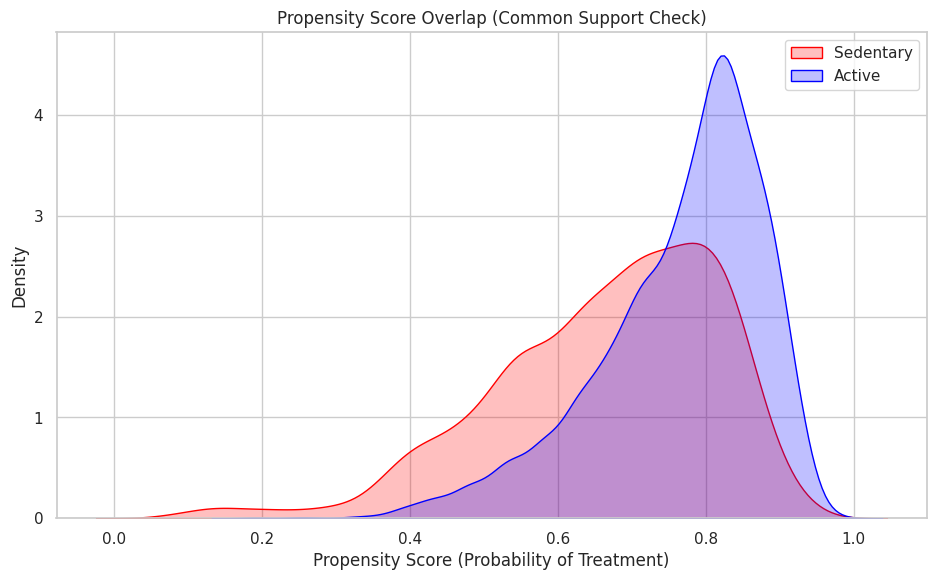

In [6]:
# Check if there is "Common Support" between the treated and control groups.
navigator.check_overlap(X_demo, T_demo)

### `fit_estimate(X, T, Y)`

**Purpose**: Trains the meta-learner and estimates CATE (Conditional Average
Treatment Effect).

- **Inputs**: Covariates `X`, Treatment `T`, Outcome `Y`
- **Output**: `numpy.array` of CATE values - one per observation
- **Design choice**: XGBoost is used as the base learner because it handles
  non-linearities in the response surface effectively, which is crucial for
  the X-Learner

In [7]:
# Estimate effects.
cate_estimates = navigator.fit_estimate(X_demo, T_demo, Y_demo)
print(f"\nAverage Treatment Effect (ATE): {cate_estimates.mean():.4f}")


Average Treatment Effect (ATE): 0.0008


### `get_cate_df(df_original)`

**Purpose**: Helper to merge the estimated effects back into the original
dataframe.

- **Inputs**: Original dataframe
- **Output**: Dataframe with a new `cate` column

### `plot_heterogeneity(df_with_cate, col, bins=5)`

**Purpose**: Visualises how the treatment effect varies across a specific
feature.

- **Inputs**: Dataframe with CATE, column name, optional bins
- **Output**: A bar chart showing CATE by group with confidence intervals

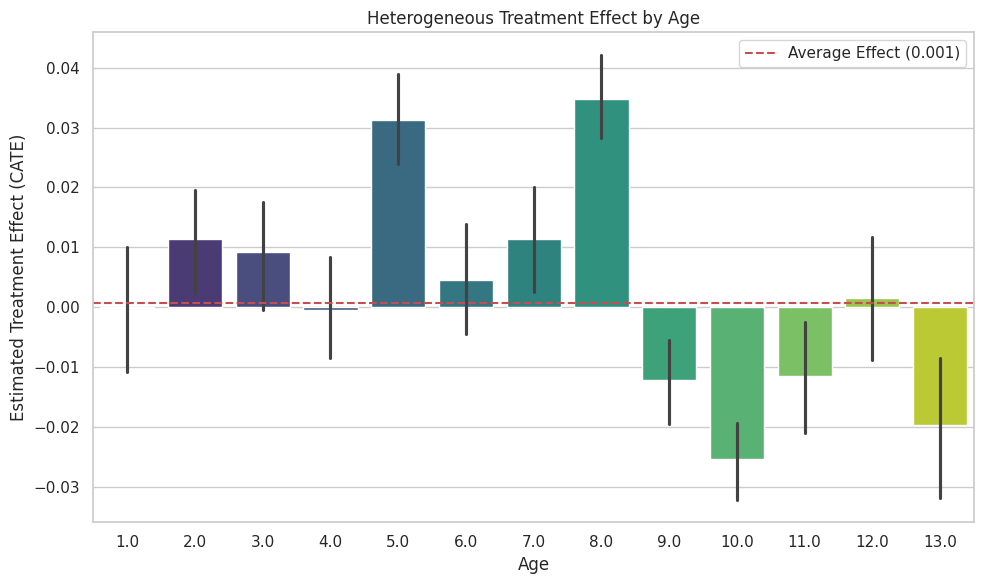

In [8]:
# Visualize results.
df_results = navigator.get_cate_df(X_demo)
navigator.plot_heterogeneity(df_results, col="Age")

### `run_placebo_test(X, T, Y, n_simulations=10)`

**Purpose**: Robustness check (Refutation).

- **Logic**: Randomly shuffles the treatment array to break any true causal
  link, then re-trains the model
- **Success criteria**: The "Placebo ATE" should cluster around 0; the
  "Actual ATE" should be far outside this distribution
- **Interpretation**: If the actual effect falls *inside* the placebo
  distribution, the result is statistically indistinguishable from noise

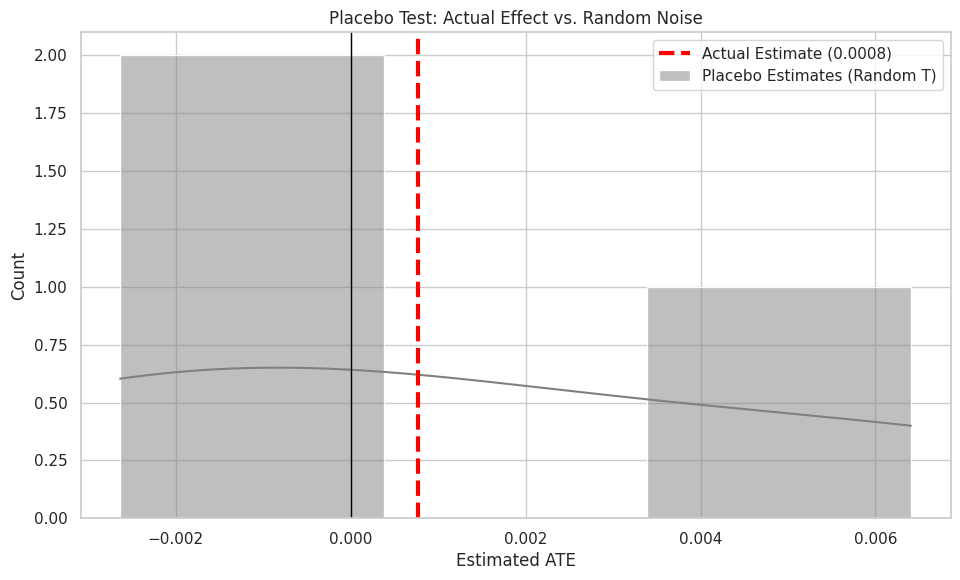

In [9]:
# Robustness check: shuffle T to see if the model finds an effect where none
# exists.
navigator.run_placebo_test(X_demo, T_demo, Y_demo, n_simulations=3)

### `run_sensitivity_analysis(X, T, Y)`

**Purpose**: Quantifies the stability of the causal estimate.

- **Logic**: Iteratively removes one covariate at a time and re-calculates
  the Average Treatment Effect (ATE)
- **Output**: A horizontal bar chart showing the ATE for each scenario
  compared to the baseline
- **Interpretation**:
  - **Stable** - bars cluster near the baseline (red line)
  - **Sensitive** - a bar shifts significantly or crosses zero, indicating
    that specific variable drives the result

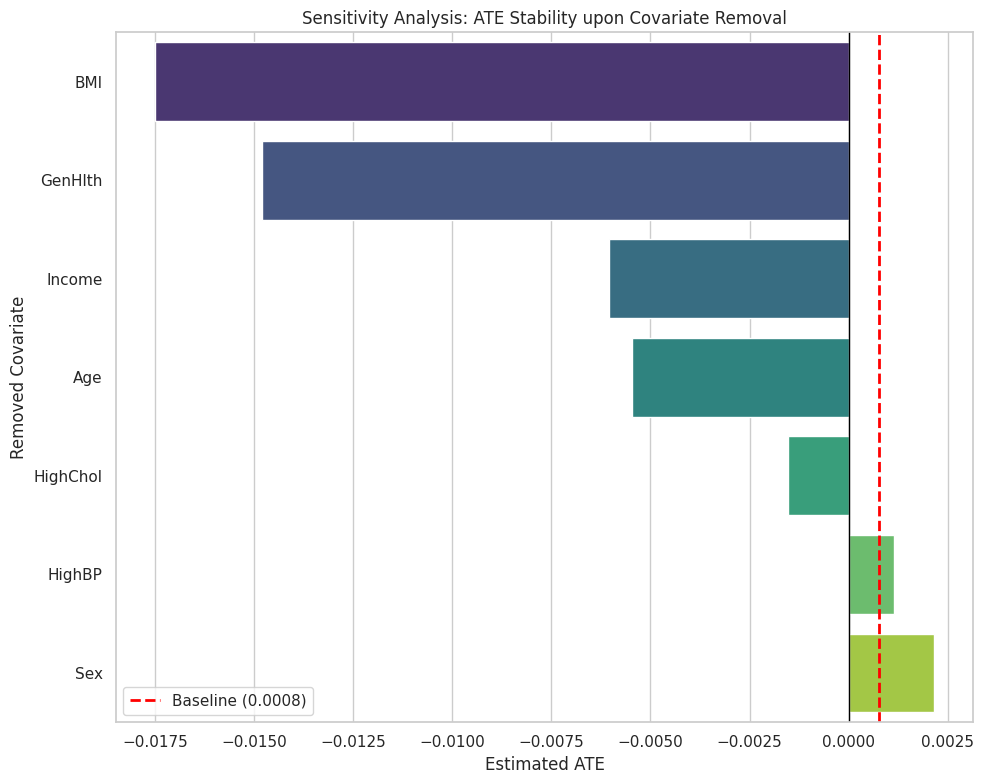

In [10]:
# Sensitivity analysis: check how stable the result is when removing one
# covariate at a time.
navigator.run_sensitivity_analysis(X_demo, T_demo, Y_demo)

### `compare_estimators(X, T, Y)`

**Purpose**: Advanced model selection ("Horse Race").

- **Methodology**: Splits data into Train (70%) and Test (30%); trains S, T,
  X, R, and DR learners on the training set
- **Metric**: Generates a **Cumulative Gain Chart (Uplift Curve)** on the
  test set
- **Why this metric**: Since ground-truth CATE is impossible to observe, RMSE
  cannot be used. The Gain Chart measures how well a model sorts individuals
  from "High Responder" to "Low Responder"
- **Outputs**:
  - **Uplift Curve Plot** - visual comparison of model performance
  - **Qini/AUUC Score Table** - numerical ranking of models (Area Under
    Uplift Curve)

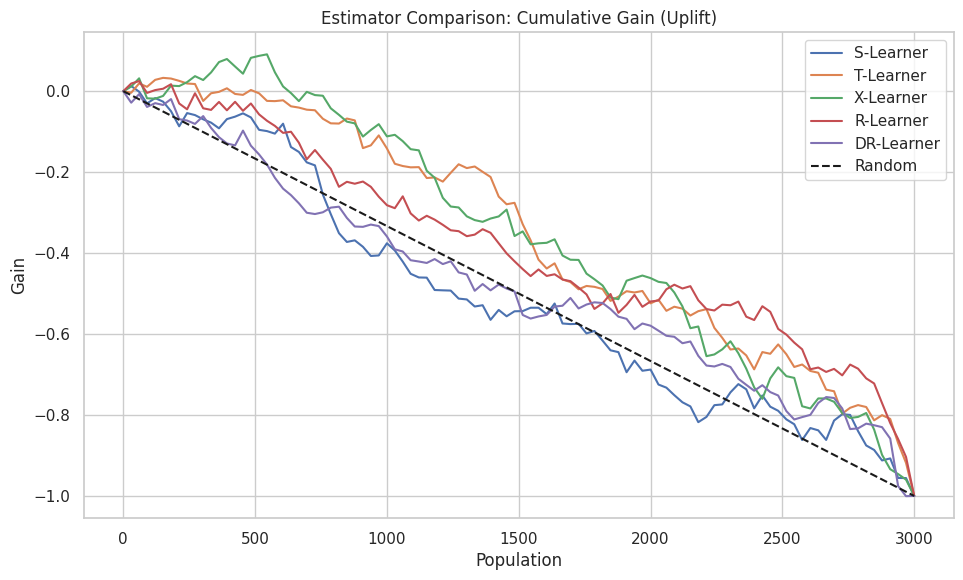

In [11]:
# Estimator comparison ("Horse Race"): compare X-Learner against S, T, R, and
# DR Learners using Uplift Curves.
navigator.compare_estimators(X_demo, T_demo, Y_demo)